# 11 — Complex Numbers; Quadratic Equations in the Complex Number System

**Equations and Inequalities ▸ 3.** Last session ended with a puzzle. When the
discriminant $\Delta = b^2 - 4ac$ is **negative**, the quadratic formula asks us for
$\sqrt{\text{negative}}$ — and in the real numbers that does **not exist**, because a
square is never negative. So a parabola like $y = x^2 + 1$ never touches the $x$-axis:
**no real roots**.

Today we *repair* this. We invent one new number, called $i$, whose only job is to make
$i^2 = -1$. Add it to the reals and you get the **complex numbers** $\mathbb{C}$. Inside
$\mathbb{C}$, **every** quadratic has roots — and, amazingly, so does *every* polynomial
(the Fundamental Theorem of Algebra). We finally solve the $\Delta < 0$ case.

Mental picture: the real numbers live on a **line**. Complex numbers live on a **plane**.
A complex number $a+bi$ is just the point $(a, b)$. Adding is like adding arrows;
multiplying, as we will see later, is **rotating and scaling**.

**Why it matters for AI.** Rotations, the **Fourier transform** (FFT) that underlies
signal and image processing, the **eigenvalues** that describe how a matrix stretches
space, and the "phase" in waves — all of these are cleanest in $\mathbb{C}$. A 2-D point
*is* a complex number, and multiplying by a unit complex number rotates it. Complex
eigenvalues tell you whether a dynamical system (or a recurrent network) spins, grows, or
decays. So $\mathbb{C}$ is a basic tool of the trade.

## Quick recall (spaced repetition)
From session 10 (Quadratic Equations). Solutions at the **end of §1**.

1. For $2x^2 + 3x + 5 = 0$, compute the discriminant $\Delta = b^2 - 4ac$. How many
   **real** roots does it have?
2. State the **quadratic formula** for $ax^2+bx+c=0$.
3. **(older weak spot, topic 8)** Simplify $\sqrt{(3-x)^2}$ for any real $x$.

## What we cover today
1. The **imaginary unit** $i$; **complex numbers** $a+bi$; real/imaginary parts; equality.
2. The **complex plane** (Argand diagram); **conjugate** $\bar z$ and **modulus** $|z|$.
3. **Arithmetic**: add, subtract, multiply, and **divide** (multiply by the conjugate).
4. **Theorems (all proved):** powers of $i$, conjugate rules, $z\bar z=|z|^2$, the modulus
   is multiplicative, the triangle inequality, square roots of negatives.
5. **Quadratics in $\mathbb{C}$:** the formula still works; when $\Delta<0$ the two roots
   are **complex conjugates** (proved). The **Conjugate Root Theorem**.
6. The **Fundamental Theorem of Algebra** (stated) — the big payoff.
7. Python: `sympy` and `numpy` complex arithmetic, an **Argand diagram**, solving the
   $\Delta<0$ case, and the AI hook: **multiplying by $i$ is a $90°$ rotation**.

## 1. Definitions

We could not solve $x^2 = -1$ in $\mathbb{R}$. So we *declare* a solution into existence.

> **Definition (imaginary unit).** The **imaginary unit** $i$ is a new symbol with the
> single defining property
> $$ i^2 = -1. $$
> (The name "imaginary" is historical and a bit unfair — $i$ is exactly as real as any
> other number we build by hand, like $-1$ or $\tfrac12$. It is just not on the real line.)

> **Definition (complex number).** A **complex number** is an expression
> $$ z = a + b i, \qquad a, b \in \mathbb{R}. $$
> Here $a = \operatorname{Re}(z)$ is the **real part** and $b = \operatorname{Im}(z)$ is
> the **imaginary part** (note: $\operatorname{Im}(z)=b$ is a *real* number, the
> coefficient of $i$). The set of all complex numbers is written $\mathbb{C}$.
>
> - If $b = 0$, then $z = a$ is an ordinary **real** number. So $\mathbb{R}\subset\mathbb{C}$.
> - If $a = 0$ and $b\ne 0$, then $z = bi$ is called **pure imaginary**.

> **Definition (equality).** Two complex numbers are **equal** exactly when their real
> parts match *and* their imaginary parts match:
> $$ a + bi = c + di \iff a = c \text{ and } b = d. $$
> One complex equation is therefore **two** real equations. We use this constantly.

> **Definition (the complex plane / Argand diagram).** Draw $z = a+bi$ as the point
> $(a, b)$ in the plane. The horizontal axis is the **real axis**, the vertical axis is
> the **imaginary axis**. This picture is called the **Argand diagram**.

```
        imaginary axis
             |
        b .......* z = a + bi
             |  .
             | .
   ----------+-------------- real axis
             |        a
             |
```

> **Definition (conjugate).** The **conjugate** of $z = a+bi$ is
> $$ \bar z = a - b i. $$
> Geometrically it is the mirror image of $z$ across the real axis (flip the sign of the
> imaginary part).

> **Definition (modulus / absolute value).** The **modulus** of $z = a+bi$ is the distance
> from the point $(a,b)$ to the origin:
> $$ |z| = \sqrt{a^2 + b^2}. $$
> This is exactly the Pythagoras / Euclidean distance from topic 3. For a real number
> ($b=0$) it reduces to $|a|=\sqrt{a^2}$, the ordinary absolute value — so the notation is
> consistent.

## 2. Arithmetic in $\mathbb{C}$

We compute with $a+bi$ using the ordinary rules of algebra, and every time we see $i^2$ we
replace it by $-1$. That single substitution is the whole game.

> **Addition / subtraction** (add the parts):
> $$ (a+bi) \pm (c+di) = (a\pm c) + (b\pm d)\, i. $$

> **Multiplication** (FOIL from topic 4, then use $i^2=-1$):
> $$ (a+bi)(c+di) = ac + adi + bci + bd\,i^2 = (ac - bd) + (ad + bc)\, i. $$
> You do **not** need to memorise the final formula — just FOIL and swap $i^2\to-1$.

**Division** is the clever step. To divide, we clear $i$ out of the denominator by
multiplying top and bottom by the conjugate of the denominator — exactly the
"rationalising with a conjugate" trick from topic 8, because
$(c+di)(c-di) = c^2 - (di)^2 = c^2 + d^2$ is **real** and positive:
$$
\frac{a+bi}{c+di}
= \frac{a+bi}{c+di}\cdot\frac{c-di}{c-di}
= \frac{(ac+bd) + (bc-ad)i}{c^2 + d^2}
= \frac{ac+bd}{c^2+d^2} + \frac{bc-ad}{c^2+d^2}\, i.
$$

So $\mathbb{C}$ is closed under $+,-,\times,\div$ (never dividing by $0$): it is a
**field**, just like $\mathbb{Q}$ and $\mathbb{R}$. All the field axioms from topic 1
still hold. What is **new** is that $\mathbb{C}$ has **no order** — there is no sensible
"$<$" that plays well with the arithmetic (if there were, $i>0$ or $i<0$ would both force
$i^2 = -1 > 0$, which is false). So "positive/negative" and inequalities do **not** apply
to non-real complex numbers. Size is measured by the modulus $|z|$ instead.

## 3. Theorems with full proofs

### Theorem 1 (powers of $i$ cycle with period 4)
For every integer $k\ge 0$,
$$ i^{0}=1,\quad i^{1}=i,\quad i^{2}=-1,\quad i^{3}=-i,\quad\text{and}\quad i^{k+4}=i^{k}. $$
So $i^n$ depends only on $n \bmod 4$.

**Proof.** By definition $i^2=-1$. Then $i^3 = i^2\cdot i = -i$ and
$i^4 = i^2\cdot i^2 = (-1)(-1) = 1$. For the period, $i^{k+4} = i^k\cdot i^4 = i^k\cdot 1 = i^k$.
To evaluate any $i^n$, write $n = 4q + r$ with remainder $r\in\{0,1,2,3\}$ (division
algorithm, topic 6); then $i^n = (i^4)^q\, i^r = 1^q\, i^r = i^r$. $\qquad\blacksquare$

*Example:* $i^{2027} = i^{4\cdot 506 + 3} = i^3 = -i$.

### Theorem 2 (conjugate is an algebra homomorphism)
For all $z,w\in\mathbb{C}$:
$$ \overline{z+w}=\bar z+\bar w,\qquad \overline{zw}=\bar z\,\bar w,\qquad \overline{\bar z}=z. $$
Also $z$ is **real** $\iff \bar z = z$, and $z$ is **pure imaginary** $\iff \bar z = -z$.

**Proof.** Write $z=a+bi$, $w=c+di$.

*Sum:* $z+w=(a+c)+(b+d)i$, so $\overline{z+w}=(a+c)-(b+d)i$. On the other side
$\bar z+\bar w=(a-bi)+(c-di)=(a+c)-(b+d)i$. Equal.

*Product:* $zw=(ac-bd)+(ad+bc)i$, so $\overline{zw}=(ac-bd)-(ad+bc)i$. Meanwhile
$\bar z\,\bar w=(a-bi)(c-di)=(ac-bd)-(ad+bc)i$ (FOIL, $i^2=-1$). Equal.

*Double conjugate:* $\overline{\bar z}=\overline{a-bi}=a+bi=z$.

*Real test:* $\bar z=z$ means $a-bi=a+bi$, i.e. $-b=b$, i.e. $b=0$, i.e. $z$ is real.
*Pure-imaginary test:* $\bar z=-z$ means $a-bi=-a-bi$, i.e. $a=-a$, i.e. $a=0$. $\qquad\blacksquare$

### Theorem 3 ($z\bar z = |z|^2$, and real/imaginary parts via the conjugate)
For every $z=a+bi$,
$$ z\bar z = a^2+b^2 = |z|^2 \ \ (\text{a real number} \ge 0),\qquad
   \operatorname{Re}(z)=\tfrac{z+\bar z}{2},\qquad \operatorname{Im}(z)=\tfrac{z-\bar z}{2i}. $$

**Proof.** $z\bar z=(a+bi)(a-bi)=a^2-(bi)^2=a^2-b^2i^2=a^2+b^2=|z|^2$; this is a sum of
real squares, so it is real and $\ge0$, and it is $0$ only when $a=b=0$, i.e. $z=0$.
Next $z+\bar z=(a+bi)+(a-bi)=2a=2\operatorname{Re}(z)$, and
$z-\bar z=(a+bi)-(a-bi)=2bi=2\operatorname{Im}(z)\,i$; divide. $\qquad\blacksquare$

This identity is the engine of division: $\dfrac1z=\dfrac{\bar z}{z\bar z}=\dfrac{\bar z}{|z|^2}$.

### Theorem 4 (the modulus is multiplicative)
For all $z,w\in\mathbb{C}$: $\quad |zw| = |z|\,|w|.$

**Proof.** Both sides are $\ge 0$, so it is enough to prove the squares are equal. Using
Theorem 3 and Theorem 2,
$$ |zw|^2 = (zw)\overline{(zw)} = z w\,\bar z\,\bar w = (z\bar z)(w\bar w) = |z|^2\,|w|^2 . $$
Take non-negative square roots: $|zw|=|z||w|$. $\qquad\blacksquare$

(We used commutativity to regroup $zw\bar z\bar w = (z\bar z)(w\bar w)$.)

### Theorem 5 (triangle inequality)
For all $z,w\in\mathbb{C}$: $\quad |z+w| \le |z| + |w|.$

**Proof.** First a lemma: for any complex $u$, $\operatorname{Re}(u)\le|u|$, because if
$u=x+yi$ then $\operatorname{Re}(u)=x\le\sqrt{x^2}\le\sqrt{x^2+y^2}=|u|$. Now expand the
square using Theorem 3 (write $|z|^2 = z\bar z$):
$$ |z+w|^2 = (z+w)\overline{(z+w)} = z\bar z + z\bar w + w\bar z + w\bar w
          = |z|^2 + |w|^2 + \big(z\bar w + \overline{z\bar w}\big), $$
since $w\bar z=\overline{z\bar w}$ (Theorem 2). But $u+\bar u = 2\operatorname{Re}(u)$, so
the middle term is $2\operatorname{Re}(z\bar w) \le 2|z\bar w| = 2|z||w|$ (lemma + Theorem 4,
using $|\bar w|=|w|$). Hence
$$ |z+w|^2 \le |z|^2 + 2|z||w| + |w|^2 = \big(|z|+|w|\big)^2 . $$
Both sides are $\ge 0$; take square roots. $\qquad\blacksquare$

This is the same triangle inequality as on the real line (topic 1) and for distances
(topic 3) — now for arrows in the plane: one side of a triangle is at most the sum of the
other two.

### Theorem 6 (square roots of a negative number)
Let $p > 0$. Then in $\mathbb{C}$ the equation $x^2 = -p$ has **exactly two** solutions,
$$ x = \pm\, i\sqrt{p}. $$
We call $i\sqrt p$ the **principal square root** of $-p$ and write $\sqrt{-p} = i\sqrt{p}$.

**Proof.** *These work:* $(\pm i\sqrt p)^2 = i^2\,(\sqrt p)^2 = (-1)\,p = -p.$

*No others:* suppose $x^2=-p$. Then $x^2+p=0$. Factor over $\mathbb{C}$ using $p=-i^2p$:
$$ x^2+p = x^2 - i^2 p = x^2 - (i\sqrt p)^2 = (x - i\sqrt p)(x + i\sqrt p), $$
a difference of squares (topic 4). By the Zero Product Property (topic 5, valid in any
field), $x = i\sqrt p$ or $x = -i\sqrt p$. $\qquad\blacksquare$

> **Warning — the product rule for radicals fails for negatives.** The rule
> $\sqrt a\,\sqrt b=\sqrt{ab}$ (topic 8) needed $a,b\ge 0$. If you use it blindly on
> negatives you get nonsense:
> $$ \sqrt{-4}\,\sqrt{-9} = (2i)(3i) = 6i^2 = -6, \quad\text{but}\quad \sqrt{(-4)(-9)}=\sqrt{36}=6. $$
> **Always convert to $i$ first** ($\sqrt{-4}=2i$), *then* multiply. Never merge two
> negative radicals under one root sign.

### Theorem 7 (quadratics in $\mathbb{C}$: the formula, and the $\Delta<0$ case)
Let $a,b,c$ be **real** with $a\ne 0$, and let $\Delta=b^2-4ac$. The equation
$ax^2+bx+c=0$ has, counting a repeated root twice, **exactly two** roots in $\mathbb{C}$:
$$ x = \frac{-b\pm\sqrt{\Delta}}{2a}. $$
Moreover:
- if $\Delta>0$: two distinct **real** roots;
- if $\Delta=0$: one repeated **real** root $x=-\tfrac{b}{2a}$;
- if $\Delta<0$: two **non-real complex** roots, and they are **conjugates** of each other:
$$ x = \frac{-b}{2a} \pm \frac{\sqrt{-\Delta}}{2a}\, i = \alpha \pm \beta i,\qquad
   \alpha=\frac{-b}{2a},\ \ \beta=\frac{\sqrt{4ac-b^2}}{2a}. $$

**Proof.** The completing-the-square derivation from topic 10 used only field axioms, so it
is still valid in $\mathbb{C}$:
$$ a\Big(x+\tfrac{b}{2a}\Big)^2 = \frac{b^2-4ac}{4a} \;\Longrightarrow\;
   \Big(x+\tfrac{b}{2a}\Big)^2 = \frac{\Delta}{4a^2}. $$
By Theorem 6 (if $\Delta<0$) or the real square-root method (if $\Delta\ge0$), the
right-hand side always has a square root in $\mathbb{C}$, namely $\dfrac{\sqrt\Delta}{2a}$
where $\sqrt\Delta=i\sqrt{-\Delta}$ when $\Delta<0$. Hence
$x+\tfrac{b}{2a}=\pm\tfrac{\sqrt\Delta}{2a}$, giving the formula.

When $\Delta<0$, $\sqrt\Delta=i\sqrt{-\Delta}$ with $\sqrt{-\Delta}>0$, so the two roots are
$\alpha+\beta i$ and $\alpha-\beta i$ with $\beta=\tfrac{\sqrt{-\Delta}}{2a}\ne0$: non-real
and mutually conjugate. $\qquad\blacksquare$

### Theorem 8 (Conjugate Root Theorem)
If a polynomial $p(x)=a_nx^n+\dots+a_1x+a_0$ has **real** coefficients and $z\in\mathbb{C}$
is a root, then $\bar z$ is also a root. **Complex roots of real polynomials come in
conjugate pairs.**

**Proof.** Because conjugation preserves $+$ and $\times$ (Theorem 2) and fixes every real
number ($\bar a_k=a_k$), applying the bar to $p(z)=0$ gives
$$ 0=\bar 0=\overline{p(z)}=\overline{\sum_k a_k z^k}=\sum_k \overline{a_k}\,\overline{z^k}
   =\sum_k a_k (\bar z)^k = p(\bar z). $$
So $p(\bar z)=0$. $\qquad\blacksquare$

A consequence: a real polynomial of **odd** degree must have at least one **real** root
(the non-real roots pair off, so an odd count cannot be all non-real).

### The Fundamental Theorem of Algebra (stated)
> **Theorem (Gauss).** Every non-constant polynomial with complex coefficients has at
> least one root in $\mathbb{C}$. Consequently a degree-$n$ polynomial factors completely,
> $$ p(x) = a_n (x-r_1)(x-r_2)\cdots(x-r_n), $$
> into $n$ linear factors over $\mathbb{C}$ (roots repeated by multiplicity).

We do **not** prove it here — a full proof needs tools from analysis or topology and comes
later in the journey. But this is the punchline of the whole "solve the equation" story
that started with $2x+3=0$: once you have $\mathbb{C}$, **you never need to invent a new
number again**. $\mathbb{C}$ is *algebraically closed*. Real numbers were not enough
($x^2+1=0$ had no solution); complex numbers are enough, forever.

### Recall-quiz solutions (from the top of the notebook)
1. $\Delta = 3^2 - 4(2)(5) = 9 - 40 = -31 < 0$, so **no real roots** (two complex
   conjugate roots — which we can now find!).
2. $x=\dfrac{-b\pm\sqrt{b^2-4ac}}{2a}$.
3. $\sqrt{(3-x)^2}=|3-x|=|x-3|$ — **not** $3-x$. The square root gives the non-negative
   value, so absolute value is required (the topic-8 sign trap).

## 4. Worked examples

**Example A — arithmetic.** Let $z=3+2i$, $w=1-4i$.
$$ z+w = 4-2i,\qquad z-w = 2+6i. $$
$$ zw = (3+2i)(1-4i)=3-12i+2i-8i^2 = 3-10i+8 = 11-10i. $$

**Example B — division.** Compute $\dfrac{3+2i}{1-4i}$. Multiply by $\dfrac{1+4i}{1+4i}$
(conjugate of the denominator):
$$ \frac{(3+2i)(1+4i)}{(1-4i)(1+4i)}
 = \frac{3+12i+2i+8i^2}{1^2+4^2}
 = \frac{3+14i-8}{17}
 = \frac{-5+14i}{17}
 = -\tfrac{5}{17}+\tfrac{14}{17}i. $$

**Example C — powers of $i$.** $i^{50}=i^{48}\cdot i^2 = (i^4)^{12}(-1) = -1$; and
$i^{-1}=\dfrac1i=\dfrac{\bar i}{|i|^2}=\dfrac{-i}{1}=-i.$

**Example D — the $\Delta<0$ case.** Solve $2x^2+3x+5=0$ (the recall problem). Here
$\Delta=-31$, so $\sqrt\Delta=i\sqrt{31}$ and
$$ x=\frac{-3\pm i\sqrt{31}}{4}=-\tfrac34 \pm \tfrac{\sqrt{31}}{4}\,i. $$
The two roots are conjugates, as Theorem 7 promised. Check with Vieta (topic 10):
sum $=-\tfrac32=-\tfrac{b}{a}$ ✓, product $=\big(\tfrac34\big)^2+\big(\tfrac{\sqrt{31}}4\big)^2
=\tfrac{9+31}{16}=\tfrac{40}{16}=\tfrac52=\tfrac{c}{a}$ ✓.

**Example E — build the equation from its roots.** A real quadratic with root $2-3i$ must
also have root $2+3i$ (Theorem 8). Its monic form is
$$ (x-(2-3i))(x-(2+3i)) = (x-2)^2-(3i)^2 = x^2-4x+4+9 = x^2-4x+13. $$
Notice the coefficients are real, and $\Delta=16-52=-36<0$. ✓

## 5. Python demonstrations

Python has complex numbers **built in**: it writes the imaginary unit as `j`, not `i`
(an electrical-engineering convention). So `1j` is our $i$, and `3+2j` is $3+2i$. We also
use `sympy` for exact symbolic answers and `numpy`/`matplotlib` for pictures.

In [1]:
# Python's built-in complex numbers. The imaginary unit is written 1j (not i).
z = 3 + 2j          # this is the complex number 3 + 2i
w = 1 - 4j          # this is 1 - 4i

print("z      =", z)
print("w      =", w)
print("z.real =", z.real, "   z.imag =", z.imag)   # real and imaginary PARTS (floats)
print("z + w  =", z + w)
print("z - w  =", z - w)
print("z * w  =", z * w)     # FOIL + i^2=-1, done automatically -> (11-10i)
print("z / w  =", z / w)     # conjugate trick done automatically
print("i*i    =", 1j * 1j)   # (-1+0j): confirms i^2 = -1

z      = (3+2j)
w      = (1-4j)
z.real = 3.0    z.imag = 2.0
z + w  = (4-2j)
z - w  = (2+6j)
z * w  = (11-10j)
z / w  = (-0.29411764705882354+0.8235294117647058j)
i*i    = (-1+0j)


In [2]:
# Conjugate and modulus, checked against our definitions.
import math

z = 3 + 2j
print("conjugate  z̄  =", z.conjugate())        # 3 - 2i: flip sign of imaginary part
print("modulus   |z| =", abs(z))               # sqrt(3^2 + 2^2) = sqrt(13)
print("by hand       =", math.sqrt(z.real**2 + z.imag**2))

# Theorem 3:  z * z̄  =  |z|^2  (a real number, no imaginary part)
print("z * conj(z)   =", z * z.conjugate(), " vs |z|^2 =", abs(z)**2)

conjugate  z̄  = (3-2j)
modulus   |z| = 3.605551275463989
by hand       = 3.605551275463989
z * conj(z)   = (13+0j)  vs |z|^2 = 12.999999999999998


In [3]:
# Theorem 1: powers of i cycle with period 4  ->  i^n depends only on n mod 4.
for n in range(9):
    val = (1j)**n
    # round tiny floating dust to integers so it prints cleanly as 1, i, -1, -i
    val = complex(round(val.real), round(val.imag))
    print(f"i^{n} = {val:>6}   (n mod 4 = {n % 4})")

i^0 = (1+0j)   (n mod 4 = 0)
i^1 =     1j   (n mod 4 = 1)
i^2 = (-1+0j)   (n mod 4 = 2)
i^3 =    -1j   (n mod 4 = 3)
i^4 = (1+0j)   (n mod 4 = 0)
i^5 =     1j   (n mod 4 = 1)
i^6 = (-1+0j)   (n mod 4 = 2)
i^7 =    -1j   (n mod 4 = 3)
i^8 = (1+0j)   (n mod 4 = 0)


In [4]:
# sympy: EXACT complex arithmetic and solving. sympy writes the imaginary unit as I.
import sympy as sp

I = sp.I                       # the exact imaginary unit i (with I**2 = -1)
z = 3 + 2*I
w = 1 - 4*I

print("z*w exactly     =", sp.expand(z*w))                 # 11 - 10i
print("z/w exactly     =", sp.simplify(z/w))               # -5/17 + 14/17 i
print("conjugate of z  =", sp.conjugate(z))                # 3 - 2i
print("Re, Im of z     =", sp.re(z), sp.im(z))             # 3, 2
print("|z| exactly     =", sp.Abs(z))                      # sqrt(13)
print("i^2027          =", sp.simplify(I**2027))           # -i (Theorem 1)

z*w exactly     = 11 - 10*I
z/w exactly     = -5/17 + 14*I/17
conjugate of z  = 3 - 2*I
Re, Im of z     = 3 2
|z| exactly     = sqrt(13)
i^2027          = -I


In [5]:
# Solve the Delta<0 quadratic 2x^2 + 3x + 5 = 0 exactly, three ways.
import sympy as sp
x = sp.symbols('x')

roots = sp.solve(2*x**2 + 3*x + 5, x)          # sympy solves over the complex numbers
print("sympy roots :", roots)                  # -3/4 ± (sqrt(31)/4) i  -> conjugate pair

# Same thing from the quadratic formula by hand, with a, b, c:
a, b, c = 2, 3, 5
Delta = b**2 - 4*a*c
print("Delta       :", Delta)                  # -31  (< 0)
sqrtDelta = sp.sqrt(Delta)                     # sympy returns sqrt(-31) = i*sqrt(31)
print("x = (-b ± √Δ)/2a :", sp.simplify((-b + sqrtDelta)/(2*a)),
                          ",", sp.simplify((-b - sqrtDelta)/(2*a)))

# numpy.roots works numerically over C too (coeffs high-degree first):
import numpy as np
print("numpy roots :", np.roots([2, 3, 5]))    # -0.75 ± 1.392j

sympy roots : [-3/4 - sqrt(31)*I/4, -3/4 + sqrt(31)*I/4]
Delta       : -31
x = (-b ± √Δ)/2a : -3/4 + sqrt(31)*I/4 , -3/4 - sqrt(31)*I/4


numpy roots : [-0.75+1.39194109j -0.75-1.39194109j]


In [6]:
# Verify Theorem 8 (Conjugate Root Theorem) and Vieta for Example E.
import numpy as np
# Real quadratic x^2 - 4x + 13 built from the pair 2 ± 3i:
r = np.roots([1, -4, 13])
print("roots of x^2-4x+13 :", r)               # 2+3j and 2-3j  -> conjugates
print("are they conjugates? ", np.allclose(r[0], np.conjugate(r[1])))
print("sum  (should be 4)  :", np.round(r.sum().real, 12), " imag:", np.round(r.sum().imag, 12))
print("prod (should be 13) :", np.round(np.prod(r).real, 12))

roots of x^2-4x+13 : [2.+3.j 2.-3.j]
are they conjugates?  True
sum  (should be 4)  : 4.0  imag: 0.0
prod (should be 13) : 13.0


In [7]:
# The classic trap: sqrt(-4)*sqrt(-9) is NOT sqrt(36). Convert to i FIRST.
import cmath   # cmath = complex math; cmath.sqrt returns the principal complex root

wrong = cmath.sqrt(-4) * cmath.sqrt(-9)     # (2i)(3i) = -6   <-- correct value
naive = cmath.sqrt((-4)*(-9))               # sqrt(36) = 6    <-- WRONG if you merge roots
print("sqrt(-4)*sqrt(-9)  =", wrong)        # -6  (up to tiny float dust)
print("sqrt((-4)*(-9))    =", naive)        # 6
print("They differ -> never merge two negative radicals under one root sign.")

sqrt(-4)*sqrt(-9)  = (-6+0j)
sqrt((-4)*(-9))    = (6+0j)
They differ -> never merge two negative radicals under one root sign.


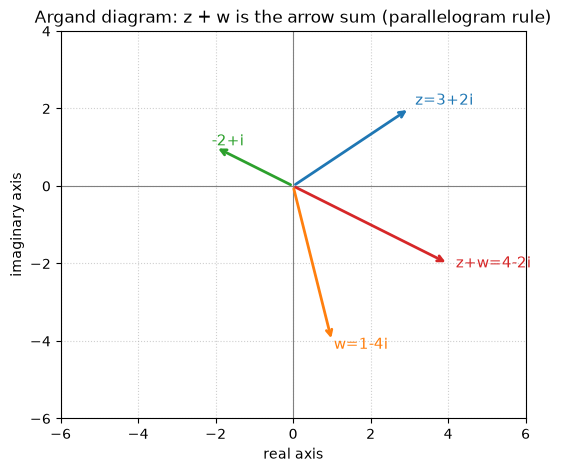

In [8]:
# Argand diagram: complex numbers are POINTS/ARROWS in the plane.
import numpy as np
import matplotlib.pyplot as plt

nums   = [3+2j, 1-4j, -2+1j, (3+2j)+(1-4j)]           # z, w, another, and z+w
labels = ['z=3+2i', 'w=1-4i', '-2+i', 'z+w=4-2i']
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']

fig, ax = plt.subplots(figsize=(6, 6))
for c, lab, col in zip(nums, labels, colors):
    # draw an arrow from the origin to the point (Re, Im)
    ax.annotate('', xy=(c.real, c.imag), xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color=col, lw=2))
    ax.text(c.real*1.05, c.imag*1.05, lab, color=col, fontsize=11)

ax.axhline(0, color='gray', lw=0.8); ax.axvline(0, color='gray', lw=0.8)
ax.set_xlim(-6, 6); ax.set_ylim(-6, 4); ax.set_aspect('equal')  # equal aspect: true angles
ax.set_xlabel('real axis'); ax.set_ylabel('imaginary axis')
ax.set_title('Argand diagram: z + w is the arrow sum (parallelogram rule)')
ax.grid(True, ls=':', alpha=0.6)
plt.show()

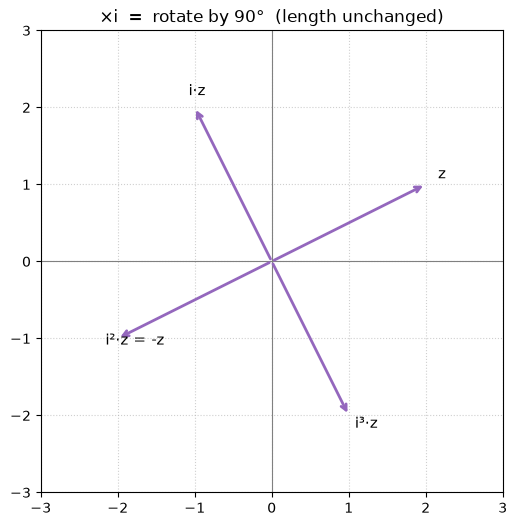

           z: (2+1j),   |·| = 2.2361
         i·z: (-1+2j),   |·| = 2.2361
   i²·z = -z: (-2-1j),   |·| = 2.2361
        i³·z: (1-2j),   |·| = 2.2361


In [9]:
# AI HOOK: multiplying by i is a 90° rotation (this is why C runs graphics/FFT/rotations).
import numpy as np
import matplotlib.pyplot as plt

z = 2 + 1j                      # a starting arrow
seq = [z, 1j*z, (1j)**2*z, (1j)**3*z]     # multiply by i again and again
labels = ['z', 'i·z', 'i²·z = -z', 'i³·z']

fig, ax = plt.subplots(figsize=(6, 6))
for c, lab in zip(seq, labels):
    ax.annotate('', xy=(c.real, c.imag), xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='tab:purple', lw=2))
    ax.text(c.real*1.08, c.imag*1.08, lab, fontsize=11)

# each multiply by i turns the arrow a quarter-turn (90°) counter-clockwise,
# keeping the length |i·z| = |i||z| = |z| the same (Theorem 4).
ax.axhline(0, color='gray', lw=0.8); ax.axvline(0, color='gray', lw=0.8)
ax.set_xlim(-3, 3); ax.set_ylim(-3, 3); ax.set_aspect('equal')
ax.set_title('×i  =  rotate by 90°  (length unchanged)')
ax.grid(True, ls=':', alpha=0.6)
plt.show()

for c, lab in zip(seq, labels):
    print(f"{lab:>12}: {c},   |·| = {abs(c):.4f}")   # all moduli equal

## 6. Exercises (fill in the cells yourself)

Work these by hand first, then check with `sympy`/`numpy`. Easy $\to$ hard; the last few
are proofs. Write $i$ in math, but remember Python uses `1j` and sympy uses `I`.

**Arithmetic & basics**
1. Write in standard form $a+bi$: (a) $(2+5i)+(4-3i)$, (b) $(7-2i)-(1+6i)$.
2. Multiply and simplify: (a) $(3-i)(2+4i)$, (b) $(5+2i)^2$, (c) $(4-3i)(4+3i)$.
3. Simplify the powers of $i$: (a) $i^{18}$, (b) $i^{45}$, (c) $i^{-7}$, (d) $i^{100}$.
4. Compute the conjugate and the modulus of (a) $-3+4i$, (b) $6i$, (c) $-5$.
5. Divide and write in standard form: (a) $\dfrac{2+3i}{1-i}$, (b) $\dfrac{5}{2+i}$,
   (c) $\dfrac{1}{i}$.

**Square roots of negatives & quadratics**
6. Write using $i$: (a) $\sqrt{-49}$, (b) $\sqrt{-12}$, (c) $\sqrt{-2}\cdot\sqrt{-8}$
   (careful — convert first!).
7. Solve over $\mathbb{C}$: (a) $x^2 = -25$, (b) $x^2 + 9 = 0$, (c) $(x-1)^2 = -16$.
8. Solve with the quadratic formula: (a) $x^2 - 4x + 13 = 0$, (b) $x^2 + 2x + 5 = 0$.
9. Solve $3x^2 - 2x + 1 = 0$. Give the roots as $\alpha \pm \beta i$ with exact fractions.
10. For each, first compute $\Delta$ and say real/complex, then solve:
    (a) $x^2 - 6x + 10 = 0$, (b) $4x^2 + 1 = 0$, (c) $x^2 - 5x + 6 = 0$.

**Reverse & structure**
11. Find a quadratic with **real** coefficients that has $3 - 2i$ as a root (use Theorem 8).
12. Find a quadratic with real coefficients whose roots are $\pm 5i$.
13. Verify **Vieta** for $x^2 - 4x + 13 = 0$: check that the sum of the two complex roots is
    $4$ and the product is $13$.
14. Let $z = 4 - 3i$. Compute $z\bar z$, $|z|$, $z + \bar z$, and $z - \bar z$, and say which
    of these are real and which are pure imaginary (link to Theorem 3).
15. Find all complex $z$ with $|z| = 5$ **and** $\operatorname{Re}(z) = 3$. (How many? Draw them.)

**Harder / proofs**
16. Show that $(1+i)^2 = 2i$, and use it to compute $(1+i)^{8}$ quickly.
17. Solve the degree-4 equation $x^4 - 1 = 0$ over $\mathbb{C}$ (the four **4th roots of
    unity**). Plot them on an Argand diagram — what shape do they make?
18. **Prove** that for all $z,w\in\mathbb{C}$, $\ \overline{z/w}=\bar z/\bar w$ (for $w\ne0$).
    (Hint: start from $z=(z/w)\cdot w$ and apply Theorem 2.)
19. **Prove** that $|z|=0 \iff z=0$, and that $|\,\bar z\,|=|z|$ for every $z$.
20. **Prove** the Conjugate Root Theorem (Theorem 8) in your own words, then use it to
    prove the corollary: *every real polynomial of odd degree has at least one real root.*

In [10]:
# Exercise 1 — your work here


In [11]:
# Exercise 2 — your work here


In [12]:
# Exercise 3 — your work here


In [13]:
# Exercise 4 — your work here


In [14]:
# Exercise 5 — your work here


In [15]:
# Exercise 6 — your work here


In [16]:
# Exercise 7 — your work here


In [17]:
# Exercise 8 — your work here


In [18]:
# Exercise 9 — your work here


In [19]:
# Exercise 10 — your work here


In [20]:
# Exercise 11 — your work here


In [21]:
# Exercise 12 — your work here


In [22]:
# Exercise 13 — your work here


In [23]:
# Exercise 14 — your work here


In [24]:
# Exercise 15 — your work here


In [25]:
# Exercise 16 — your work here


In [26]:
# Exercise 17 — your work here


In [27]:
# Exercise 18 — your work here


In [28]:
# Exercise 19 — your work here


In [29]:
# Exercise 20 — your work here


## 7. `uv` note — how to run this notebook

This project is managed with **`uv`** (a fast Python package manager). From the project
root (`C:\dev\math`):

- `uv sync` — create/refresh the virtual environment and install dependencies
  (`numpy`, `sympy`, `matplotlib`, `jupyterlab`) from `pyproject.toml`.
- `uv run jupyter lab` — launch Jupyter Lab, then open
  `notebooks/11-complex-numbers.ipynb`.
- To add a library later: `uv add <package>` (e.g. `uv add pandas`).
- To re-run the whole notebook top-to-bottom from the terminal (a good self-test):
  `uv run jupyter nbconvert --to notebook --execute notebooks/11-complex-numbers.ipynb`.

Everything here is self-contained — restart the kernel and **Run All** to repeat the
tutorial any time. `1j` in Python, `I` in sympy, and $i$ on paper all mean the same thing.